# Hyperedges in the Surface Code DEM

Standard MWPM decoders model the surface code as a graph whose edges connect **at most two** detectors. But under circuit-level depolarizing noise, single physical errors can trigger **three or four** detectors at once — these are *hyperedges* in the Detector Error Model (DEM).

This notebook visualises which physical error mechanisms produce hyperedges, and where their detection events land in space-time. We use a distance-3 rotated surface code with 3 syndrome rounds (Z-memory), and inject deterministic Pauli errors at specific points in the *noiseless* circuit to isolate each mechanism.

**Mechanisms shown:**
1. Ancilla reset X error — degree 2 (time edge)
2. X error on a data qubit — degree 2 (space edge)
3. `DEPOLARIZE2` XX on a CNOT — degree 2 (not a hyperedge)
4. `DEPOLARIZE2` ZZ on a CNOT — degree 2 (not a hyperedge)
5. Y error on a bulk data qubit — **degree 4 hyperedge**
6. `DEPOLARIZE2` YY on a CNOT — **degree 4 hyperedge**
7. `DEPOLARIZE2` XY on a CNOT — **degree 4 hyperedge** (different pattern)
8. **Z-hook on a Z-ancilla** — pure-X hyperedge (ancilla error propagated to two data qubits via remaining CXes)

Throughout, *degree* = number of detectors flipped by a single occurrence of the mechanism.

In [ ]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from collections import Counter

DISTANCE = 3
ROUNDS = 3

# Noiseless reference circuit — we inject deterministic Paulis into copies of this.
clean_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=DISTANCE,
    rounds=ROUNDS,
    after_clifford_depolarization=0.0,
    after_reset_flip_probability=0.0,
    before_measure_flip_probability=0.0,
    before_round_data_depolarization=0.0,
)

# Noisy version used only for the DEM-statistics histogram below.
noisy_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=DISTANCE,
    rounds=ROUNDS,
    after_clifford_depolarization=1e-3,
    after_reset_flip_probability=1e-3,
    before_measure_flip_probability=1e-3,
    before_round_data_depolarization=1e-3,
)

qubit_coords = clean_circuit.get_final_qubit_coordinates()
detector_coords = clean_circuit.get_detector_coordinates()
print(f"qubits: {len(qubit_coords)}  |  detectors: {len(detector_coords)}")

## How many DEM mechanisms are hyperedges?

We pull every elementary error mechanism from the DEM (with `decompose_errors=False`, so Stim does *not* split hyperedges into pairs) and count how many detectors each one flips.

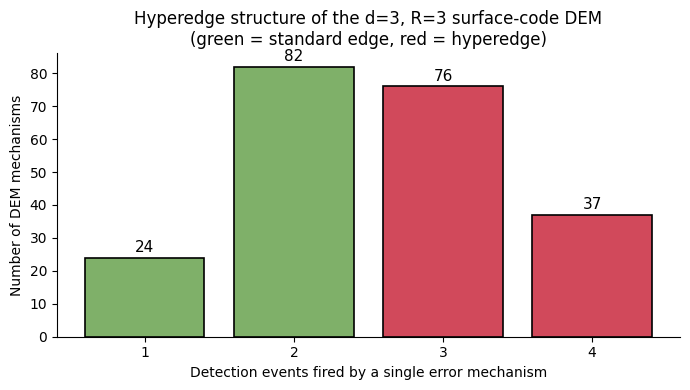

113/219 mechanisms (51.6%) are hyperedges (>2 detectors).


In [58]:
dem = noisy_circuit.detector_error_model(decompose_errors=False)

degree_counts = Counter()
for inst in dem.flattened():
    if inst.type == "error":
        n_dets = sum(1 for t in inst.targets_copy() if t.is_relative_detector_id())
        degree_counts[n_dets] += 1

ks = sorted(degree_counts)
vals = [degree_counts[k] for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#7fb069' if k <= 2 else '#d1495b' for k in ks]
bars = ax.bar(ks, vals, color=bar_colors, edgecolor='black', linewidth=1.2)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01, str(v),
            ha='center', va='bottom', fontsize=11)
ax.set_xticks(ks)
ax.set_xlabel('Detection events fired by a single error mechanism')
ax.set_ylabel('Number of DEM mechanisms')
ax.set_title(f'Hyperedge structure of the d={DISTANCE}, R={ROUNDS} surface-code DEM\n'
             '(green = standard edge, red = hyperedge)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

n_hyper = sum(v for k, v in degree_counts.items() if k > 2)
n_total = sum(degree_counts.values())
print(f"{n_hyper}/{n_total} mechanisms ({100*n_hyper/n_total:.1f}%) are hyperedges (>2 detectors).")

## Plotting helpers

Each event is shown in a single interactive 3D Plotly plot — `x` and `y` are lattice coordinates, the vertical axis is the syndrome round. The style matches `visualizations/shot_analysis_gallery.html`.

- **All detector nodes are the same size**; only their colour differs.
- **Firebrick `#b22222` → idle X-detector**;  **bright red `#ff4d4d` → fired X-detector**.
- **Dark blue `#005f87` → idle Z-detector**;  **bright blue `#33aaff` → fired Z-detector**.
- **Light gray lines** → decoding-graph edges (spatial within a round + the time edges connecting each ancilla to itself in the next round).
- **Gold lines** → the hyperedge: every fired detector comes from the same underlying error mechanism, so they are linked pairwise.

Round 0 contains only Z-detectors (memory_z initialises in the +1 Z-eigenspace, so X-detectors only kick in from round 1). The final round contains the data-qubit-readout reconstructions of the Z-stabilisers.

In [59]:
# In d=3 rotated_memory_z, the X-stabilizer ancillas sit at these XY positions:
X_ANCILLA_XY = {(2.0, 0.0), (4.0, 2.0), (2.0, 4.0), (4.0, 6.0)}

def is_x_type(xy):
    return (round(xy[0], 6), round(xy[1], 6)) in X_ANCILLA_XY

def inject_after_tick(circ, n_tick, error_op, qubits):
    """Insert ERROR_OP with probability 1 on `qubits` right after the n-th TICK."""
    out = stim.Circuit()
    seen = 0
    inserted = False
    for inst in circ.flattened():
        out.append(inst)
        if inst.name == 'TICK':
            seen += 1
            if seen == n_tick and not inserted:
                out.append(error_op, qubits, 1.0)
                inserted = True
    return out

def inject_after_cnot(circ, cx_idx, paulis):
    """Insert a CORRELATED_ERROR(p=1) acting as `paulis` right after the cx_idx-th CX instruction.
    paulis: list of (qubit, axis) with axis in {'X','Y','Z'}."""
    target_map = {'X': stim.target_x, 'Y': stim.target_y, 'Z': stim.target_z}
    out = stim.Circuit()
    n_cx = 0
    inserted = False
    for inst in circ.flattened():
        out.append(inst)
        if inst.name == 'CX':
            n_cx += 1
            if n_cx == cx_idx and not inserted:
                targets = [target_map[ax](q) for (q, ax) in paulis]
                out.append('CORRELATED_ERROR', targets, 1.0)
                inserted = True
    return out

def fired_detectors(circ):
    s = circ.compile_detector_sampler().sample(1)
    return np.flatnonzero(s[0]).tolist()

In [ ]:
# Visual style — matches visualizations/shot_analysis_gallery.html.
X_IDLE   = '#b22222'                   # firebrick   — idle X-detector
X_FIRED  = '#ff4d4d'                   # bright red  — fired X-detector
Z_IDLE   = '#005f87'                   # dark teal-blue — idle Z-detector
Z_FIRED  = '#33aaff'                   # bright blue — fired Z-detector
EDGE     = 'rgba(150, 150, 150, 0.25)' # standard decoding-graph edges
HYPER    = '#d4af37'                   # gold        — hyperedge highlight

def plot_event(fired, injection=None, title="", subtitle=""):
    """3D decoding-graph view in the style of visualizations/shot_analysis_gallery.html.

    All detectors are drawn the same size; idle ones use the dark colour,
    fired ones (syndrome = -1) use the bright colour. Decoding-graph edges
    are faint gray. The set of fired detectors — all from one underlying
    error mechanism — is linked pairwise by gold lines, which is the hyperedge.

    The `injection` argument is accepted for API compatibility with the
    example cells, but no marker is drawn for it.

    Returns the `plotly.graph_objects.Figure` so the caller can do `fig.show()`.
    """
    fired_set = set(fired)
    all_dets = list(detector_coords.items())
    all_rounds = sorted({int(c[2]) for c in detector_coords.values()})

    # 1) Gray decoding-graph edges.
    edge_x, edge_y, edge_z = [], [], []

    # Spatial edges: same round, same type, share a data qubit.
    for r in all_rounds:
        round_dets = [(d, c) for d, c in all_dets if int(c[2]) == r]
        for i, (_, c1) in enumerate(round_dets):
            for _, c2 in round_dets[i + 1:]:
                if is_x_type((c1[0], c1[1])) != is_x_type((c2[0], c2[1])):
                    continue
                if abs(c1[0] - c2[0]) == 2 and abs(c1[1] - c2[1]) == 2:
                    edge_x += [c1[0], c2[0], None]
                    edge_y += [c1[1], c2[1], None]
                    edge_z += [c1[2], c2[2], None]

    # Temporal edges: same ancilla, consecutive rounds.
    pos_to_dets = {}
    for d, (x, y, t) in all_dets:
        pos_to_dets.setdefault((round(x, 6), round(y, 6)), []).append((int(t), d))
    for (x, y), ds in pos_to_dets.items():
        ds.sort()
        for (t1, _), (t2, _) in zip(ds[:-1], ds[1:]):
            if t2 == t1 + 1:
                edge_x += [x, x, None]
                edge_y += [y, y, None]
                edge_z += [t1, t2, None]

    # 2) Gold hyperedge lines: all pairs of fired detectors.
    hyper_x, hyper_y, hyper_z = [], [], []
    fired_pts = [detector_coords[d] for d in fired]
    for i, c1 in enumerate(fired_pts):
        for c2 in fired_pts[i + 1:]:
            hyper_x += [c1[0], c2[0], None]
            hyper_y += [c1[1], c2[1], None]
            hyper_z += [c1[2], c2[2], None]

    # 3) Detector nodes — uniform size, colour-coded by type + fired/idle.
    node_x, node_y, node_z, node_c, node_t = [], [], [], [], []
    for d, (x, y, t) in all_dets:
        is_x = is_x_type((x, y))
        if d in fired_set:
            color = X_FIRED if is_x else Z_FIRED
            label = f"D{d} (FIRED, {'X' if is_x else 'Z'}-type, round {int(t)})"
        else:
            color = X_IDLE if is_x else Z_IDLE
            label = f"D{d} ({'X' if is_x else 'Z'}-type, round {int(t)})"
        node_x.append(x); node_y.append(y); node_z.append(t)
        node_c.append(color); node_t.append(label)

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z, mode='lines',
        line=dict(color=EDGE, width=2),
        hoverinfo='skip', showlegend=False, name='decoding edges',
    ))

    if hyper_x:
        fig.add_trace(go.Scatter3d(
            x=hyper_x, y=hyper_y, z=hyper_z, mode='lines',
            line=dict(color=HYPER, width=7),
            hoverinfo='skip', showlegend=False, name='hyperedge',
        ))

    fig.add_trace(go.Scatter3d(
        x=node_x, y=node_y, z=node_z, mode='markers',
        marker=dict(color=node_c, size=6, line=dict(color='white', width=1)),
        text=node_t, hoverinfo='text', showlegend=False, name='detectors',
    ))

    full_title = title
    if subtitle:
        full_title += f"<br><sup>{subtitle}</sup>"

    fig.update_layout(
        title=dict(text=full_title, x=0.5, xanchor='center'),
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='round',
            xaxis=dict(showgrid=True, gridcolor='#eee', zeroline=False),
            yaxis=dict(showgrid=True, gridcolor='#eee', zeroline=False),
            zaxis=dict(showgrid=True, gridcolor='#eee', zeroline=False,
                       tickvals=all_rounds),
            aspectmode='cube',
            camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
            bgcolor='white',
        ),
        width=780, height=620,
        margin=dict(l=0, r=0, t=70, b=0),
        paper_bgcolor='white',
    )
    return fig

## 1. Ancilla reset X error → degree 2 (time edge)

An X flip on a Z-ancilla right after `R` flips the ancilla state from |0⟩ to |1⟩. The X commutes with the subsequent CNOTs (the ancilla is the target side, so X stays put). At measurement, the ancilla reads `1` instead of `0` — that flips two detectors: the round-0 detector (which is a direct measurement against the +1 stabilizer reference) **and** the round-1 detector (which compares round-1 to the flipped round-0).

This is a *degree-2 time edge* — same stabilizer, two consecutive rounds. Not a hyperedge.

In [61]:
# Tick 1 lands immediately after R / before the first H+CX layer of round 0.
circ = inject_after_tick(clean_circuit, n_tick=1, error_op='X_ERROR', qubits=[9])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(2.0, 2.0, 0.0, 'X on q9 (Z-ancilla reset)'),
    title='Ancilla reset X-flip — degree-2 time edge',
    subtitle='X_ERROR on Z-ancilla q9 just after R; flips the round-0 detector and the round-1 comparator.'
)
fig.show()

Fired detectors: [1, 5]  (count = 2)


## 2. X error on a data qubit → degree 2 (space edge)

An X on a bulk data qubit anti-commutes with the **Z-stabilizers** that share it. In the bulk every data qubit borders two Z-stabilizers, so the next round's comparator on each of those Z-ancillas flips. This is the canonical *degree-2 space edge* that MWPM is purpose-built for.

In [62]:
# Tick 7 sits between round 0 and round 1, after the round-0 measurement.
# q10 = (3,3) is the centre data qubit, bordering Z-ancillas q9=(2,2) and q18=(4,4).
circ = inject_after_tick(clean_circuit, n_tick=7, error_op='X_ERROR', qubits=[10])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.0, 3.0, 0.5, 'X on q10 (data)'),
    title='Data-qubit X error — degree-2 space edge (standard MWPM)',
    subtitle='X_ERROR on bulk data q10 between rounds 0 and 1; flips both neighbouring Z-stabilizers in round 1.'
)
fig.show()

Fired detectors: [5, 10]  (count = 2)


## 3. `DEPOLARIZE2` XX on a CNOT → degree 2 (no hyperedge)

After every CNOT, Stim's circuit-level noise model applies `DEPOLARIZE2(p)` — a uniform mixture over the 15 non-identity two-qubit Paulis. The component **XX** is not a hyperedge: the X on the ancilla propagates through the remaining CNOTs of the round onto one extra data qubit, and the X on the data qubit affects neighbouring Z-stabilizers. The net effect of *this specific* component, at *this specific* injection site, is still 2 detectors — but already at a richer spatial pattern than the bare data-qubit X.

In [63]:
# CX-instruction #6 is the 2nd CX layer of round 1; it contains the pair (q11, q10).
circ = inject_after_cnot(clean_circuit, cx_idx=6, paulis=[(11, 'X'), (10, 'X')])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.5, 2.5, 1.0, 'XX on CNOT(q11,q10)'),
    title='CNOT XX (DEPOLARIZE2 component) — degree-2 edge',
    subtitle='XX after the round-1 CNOT q11→q10; still only 2 detectors fire.'
)
fig.show()

Fired detectors: [7, 10]  (count = 2)


## 4. `DEPOLARIZE2` ZZ on a CNOT → degree 2 (no hyperedge)

ZZ is the partner case: the Z on the ancilla flips its own measurement, and the Z on the data qubit gets seen later by the neighbouring X-stabilizers. Again only 2 detectors fire — XX and ZZ on a CNOT, like a bare data X and a bare data Z, sit firmly in the ordinary-edge regime.

In [64]:
circ = inject_after_cnot(clean_circuit, cx_idx=6, paulis=[(11, 'Z'), (10, 'Z')])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.5, 2.5, 1.0, 'ZZ on CNOT(q11,q10)'),
    title='CNOT ZZ (DEPOLARIZE2 component) — degree-2 edge',
    subtitle='ZZ after the round-1 CNOT q11→q10; only 2 detectors fire.'
)
fig.show()

Fired detectors: [6, 9]  (count = 2)


## 5. Y error on a bulk data qubit → degree 4 HYPEREDGE

Now the textbook hyperedge. Y = X · Z, so a Y on a data qubit anti-commutes with **both** kinds of neighbouring stabilizer. A bulk data qubit borders 2 X-ancillas and 2 Z-ancillas, so a single Y fires **four** detectors at once. This is the hyperedge a decomposed MWPM has to model as a *pair* of correlated edges sharing the same underlying mechanism.

In [ ]:
# Tick 8 lands right at the start of round 1, where the per-round data
# depolarization channel is applied (i.e. before the round-1 H/CX layers).
# A Y injected here propagates cleanly through the round-1 syndrome extraction
# and fires all four neighbouring stabilizers in the same round.
circ = inject_after_tick(clean_circuit, n_tick=8, error_op='Y_ERROR', qubits=[10])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.0, 3.0, 1.0, 'Y on q10 (data depolarization, round 1)'),
    title='Bulk Y on data qubit (data-depolarization step) — degree-4 HYPEREDGE',
    subtitle='Y_ERROR on bulk data q10 at the start of round 1 (data-depolarization position); '
             'X-part fires the 2 neighbouring Z-stabilizers, Z-part fires the 2 neighbouring X-stabilizers, '
             'all in the same round.'
)
fig.show()

## 6. `DEPOLARIZE2` YY on a CNOT → degree 4 HYPEREDGE

Going back to the same `DEPOLARIZE2` component channel, but now picking the **YY** Pauli: each Y splits into an X-part and a Z-part, and at this point in round 1 those parts propagate to four distinct stabilizer ancillas. One DEPOLARIZE2 component out of 15 is enough to produce a 4-detector hyperedge — and there is one such channel after *every* CNOT in the circuit.

In [66]:
circ = inject_after_cnot(clean_circuit, cx_idx=6, paulis=[(11, 'Y'), (10, 'Y')])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.5, 2.5, 1.0, 'YY on CNOT(q11,q10)'),
    title='CNOT YY (DEPOLARIZE2 component) — degree-4 HYPEREDGE',
    subtitle='YY after the round-1 CNOT q11→q10; one DEPOLARIZE2 component fires 4 detectors.'
)
fig.show()

Fired detectors: [6, 7, 9, 10]  (count = 4)


## 7. `DEPOLARIZE2` XY on a CNOT → degree 4 HYPEREDGE (different pattern)

Different two-qubit Paulis from the same DEPOLARIZE2 channel produce different hyperedges. XY on `(q11, q10)` at the same injection site fires a **different** 4-detector subset than YY: only the Y on the data qubit contributes both X- and Z-stabilizer flips, while the X on the ancilla propagates forward through the rest of round 1's CNOTs and reaches an additional data qubit.

In [67]:
circ = inject_after_cnot(clean_circuit, cx_idx=6, paulis=[(11, 'X'), (10, 'Y')])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(3.5, 2.5, 1.0, 'XY on CNOT(q11,q10)'),
    title='CNOT XY (DEPOLARIZE2 component) — degree-4 HYPEREDGE',
    subtitle='XY after the round-1 CNOT q11→q10; different 4-detector pattern from YY.'
)
fig.show()

Fired detectors: [7, 9, 10, 14]  (count = 4)


## 8. Z-hook on a Z-ancilla → degree-2 PURE-X hyperedge

A **hook error** is an error on an *ancilla* that occurs partway through that ancilla's CX schedule and gets propagated to several data qubits via the remaining CX gates. The mechanism is dangerous because a single physical error ends up looking like a weight-≥2 chain of correlated *data* errors.

For a Z-stabiliser measurement the ancilla is the *target* of every CX (data qubits are controls). If a Z error lands on the Z-ancilla after, say, the first CX layer, the rule `I⊗Z → Z⊗Z` propagates a Z **back to the control** at every remaining CX — i.e. onto every still-unmeasured neighbouring data qubit.

These propagated Z errors on data qubits **anti-commute only with X-stabilisers**, so the resulting hyperedge fires *only X-detectors* — no Z-detectors. The Z that stays on the ancilla itself commutes with the final Z-basis measurement, so the ancilla's own detector is silent.

This is exactly the pattern PyMatching has to handle as a single edge: a correlated weight-2 data-Z error connecting two X-detectors, indistinguishable from a single data-Z error sitting on the data qubit they share.

In [ ]:
# q9 is the bulk Z-ancilla at (2,2). It is the target of four CXes during round 1
# (one per CX layer): 10->9, 3->9, 8->9, 1->9. We inject Z on q9 right after the
# first layer (TICK 10 = between CX layers 1 and 2 of round 1) so the Z propagates
# back to q3 (via 3->9), q8 (via 8->9), and q1 (via 1->9).
#
# Of those data Z errors, q3 fires X-stab (4,2) = D6, q8 fires X-stab (2,4) = D9,
# and q1's contribution to X-stab (2,0) is cancelled by q3's contribution to the
# same X-stab — leaving a clean pair of X-detectors in round 1.
circ = inject_after_tick(clean_circuit, n_tick=10, error_op='Z_ERROR', qubits=[9])
fired = fired_detectors(circ)
print(f"Fired detectors: {fired}  (count = {len(fired)})")

fig = plot_event(
    fired,
    injection=(2.0, 2.0, 1.0, 'Z on q9 (Z-ancilla, mid-CX)'),
    title='Z-hook on Z-ancilla — pure-X hyperedge',
    subtitle='Z_ERROR on Z-ancilla q9 between CX layers 1 and 2 of round 1; '
             'propagates Z to data qubits q3 and q8, which fire only the '
             'neighbouring X-stabilisers (no Z-detectors flip).'
)
fig.show()

## Summary

- About **half** of the DEM mechanisms in this d=3 surface code (3 rounds, circuit-level depolarizing noise) are hyperedges — most of them firing 3 or 4 detectors.
- **Reset, measure, and bare X/Z errors** stay on standard edges (degree ≤ 2).
- **Y on a bulk data qubit** is the prototypical 4-detector hyperedge: Y = X · Z couples to both stabilizer types simultaneously.
- **CNOT errors are mechanism-by-mechanism**: out of the 15 two-qubit Paulis of `DEPOLARIZE2`, XX and ZZ stay at degree 2, while YY, XY, YZ, ZY, XZ, ZX, YX and the boundary components contribute the bulk of the 4-detector hyperedges.
- Standard MWPM only handles degree-≤2 edges, so PyMatching has to *decompose* each hyperedge into a pair of correlated edges. The reweighting policy in the rest of this project exists precisely to recover the lost correlation information at decode time.